<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex11_Contingency_Tables_2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA — Exercise 11: Contingency Tables (2D)

This is the 11th exercise of *01ZLMA — Generalized Linear Methods*. Two-dimensional contingency tables, three sampling distributions for count tables (Poisson, Multinomial, Product Multinomial), the family of log-linear models, and a gentle introduction to three-dimensional tables. Lecture chapter 8.

## Contents
1. [Motivation — when do we have categorical data?](#1-motivation)
2. [Three sampling distributions for count tables](#2-sampling)
3. [Two-dimensional log-linear models](#3-loglinear-2d)
4. [Worked example 1: skin cancer (Lecture §8.4.1)](#4-tumor)
5. [Worked example 2: flu vaccine (Lecture Ex. 8.2)](#5-flu)
6. [First look at three-dimensional tables](#6-first-3d)
7. [Your turn](#7-your-turn)
8. [Summary and transition to ex12](#8-summary)


<a id="0-setup"></a>
## 0. Setup

In [1]:
import io
import sys

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

import warnings
warnings.filterwarnings("ignore", message=".*observed=False.*")
warnings.filterwarnings("ignore", message=".*divide by zero encountered.*")
try:
    from statsmodels.tools.sm_exceptions import PerfectSeparationWarning
    warnings.filterwarnings("ignore", category=PerfectSeparationWarning)
except ImportError:
    pass

sns.set_theme(style="whitegrid")
np.random.seed(20260504)


In [2]:
# helpers.py: load it from local file when running outside Colab,
# otherwise fetch the GitHub raw version.
try:
    from helpers import Anova, DiagnosticPlots
except ImportError:
    if "google.colab" in sys.modules:
        import wget
        wget.download(
            "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py",
            "helpers.py",
        )
    else:
        sys.path.insert(0, ".")
    from helpers import Anova, DiagnosticPlots

anova = Anova()


In [3]:
import os

BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"


def load_csv(name: str, sep: str = ",") -> pd.DataFrame:
    """Load a CSV from the project data folder.

    Tries the GitHub raw URL first (Colab path); on a 404 falls back to
    a sibling ``data/`` directory next to the notebook (local path,
    useful when the dataset has been added but not yet pushed).
    """
    r = requests.get(BASE_URL + name, verify=False, timeout=30)
    if r.status_code == 200:
        return pd.read_csv(io.StringIO(r.text), sep=sep)
    local = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", name)
    if os.path.exists(local):
        return pd.read_csv(local, sep=sep)
    r.raise_for_status()  # surface the original HTTP error


<a id="1-motivation"></a>
## 1. Motivation — when do we have categorical data?

### 1.1 The pivot from ex07/ex08

In the binary-data block (ex07–ex08) we treated **one** categorical variable as the response and the rest as predictors — *binary logistic regression* answered "given covariates $\mathbf x$, what is the probability that $Y=1$?". We did this both for individual-level data and for grouped (rate-form) data.

In Chapter 8 we step back and ask a different question: *when **all** variables are categorical and we have not committed to one being the response*, can we still use GLM machinery to detect and quantify dependencies between them? The answer is **yes, via log-linear models on contingency tables**.


### 1.2 What "fixed by design" means — and why it matters

A *contingency table* is a multi-way array of counts, indexed by the categorical factors. The **sampling distribution** of those counts depends on what was fixed before the data were collected:

- **Nothing fixed.** A survey ran for one hour; we recorded the number of respondents in each category as they walked in. Counts are independent **Poisson** random variables.
- **Total fixed.** We sampled $n=400$ patients up front, then sorted them by tumour type × site. Conditional on $n$, counts follow a **multinomial distribution**.
- **Row totals fixed.** A trial recruited 35 vaccine + 38 placebo subjects up front, then measured antibody response. Each row is a separate multinomial — together a **product multinomial**.

The same loglinear-model machinery handles all three sampling schemes — *provided* we keep the parameters that match what was fixed by design (Birch's theorem; we will derive this later in §3.4).


### 1.3 Three motivating examples (Lecture §8.1)

**Example 8.1 (Hutchinson skin cancer).** $n=400$ patients with malignant melanoma; tumour type ∈ {Hutchinson, Superficial spreading, Nodular, Indeterminate}, site ∈ {head/neck, trunk, extremities}. Observational; only the total $n=400$ was fixed by design. Question: are tumour type and site associated?

**Example 8.2 (Flu vaccine).** Trial with 35 vaccine + 38 placebo subjects; antibody level after 6 weeks measured as low / medium / high. Row totals were fixed by recruitment. Question: do the vaccine and placebo groups have the same antibody distribution? — *hypothesis of homogeneity*.

**Example 8.3 (Aspirin and ulcers, case-control).** Four groups of pre-determined size: stomach-ulcer cases vs controls, duodenal-ulcer cases vs controls. Past aspirin use recorded. Row totals fixed in **each subtable**. Question: is past aspirin use associated with each ulcer type, and is the association the same for the two ulcer types?

These three designs anchor everything that follows. Examples 8.1, 8.2, 8.3 reappear in §4, §5, §6 of this notebook respectively.


<a id="2-sampling"></a>
## 2. Three sampling distributions for count tables (Lecture §8.2.1)

We build the three distributions side-by-side on a single dataset: the GM-food attitude survey (last year's NB), where $n=894$ Australian respondents in 1996/97 were classified by `attitude ∈ {for, against}` and `income ∈ {high, low}`.


In [4]:
gm = load_csv("gm_food.csv")
gm


,attitude,income,counts
0,for,high,263
1,for,low,258
2,against,high,151
3,against,low,222


In [5]:
# Crosstab with row/column totals
gm_table = (
    gm.assign(attitude=pd.Categorical(gm.attitude, categories=["for","against"], ordered=False),
              income=pd.Categorical(gm.income, categories=["high","low"], ordered=False))
      .pivot_table(index="attitude", columns="income", values="counts", aggfunc="sum", margins=True)
)
gm_table


income,high,low,All
attitude,,,
for,263,258,521
against,151,222,373
All,414,480,894


### 2.1 Poisson model (nothing fixed)

Each cell count $Y_{ij}$ is independent $\mathrm{Po}(\mu_{ij})$. The joint pmf is
$$
P(\mathbf Y = \mathbf y) = \prod_{i,j} \frac{e^{-\mu_{ij}}\,\mu_{ij}^{y_{ij}}}{y_{ij}!}.
$$
The grand total is itself random, $Y_{\cdot\cdot} \sim \mathrm{Po}(\mu_{\cdot\cdot})$. Concrete reading: *"the survey ran for a fixed time and we counted everyone who walked in."*


### 2.2 Multinomial model (grand total fixed)

If we condition on $Y_{\cdot\cdot} = n$, the Poisson cells become **multinomial**. With $\pi_{ij} = \mu_{ij}/\mu_{\cdot\cdot}$,
$$
P(\mathbf Y = \mathbf y \mid Y_{\cdot\cdot} = n) = \frac{n!}{\prod y_{ij}!}\,\prod \pi_{ij}^{y_{ij}}.
$$
Concrete reading: *"we recruited 894 respondents up front and asked each."*

The derivation (Lecture eq. 8.2):
$$
P(\mathbf Y = \mathbf y \mid Y_{\cdot\cdot} = n) = \frac{P(\mathbf Y = \mathbf y, Y_{\cdot\cdot}=n)}{P(Y_{\cdot\cdot}=n)} = \frac{\prod \frac{e^{-\mu_{ij}}\mu_{ij}^{y_{ij}}}{y_{ij}!}}{\frac{e^{-\mu_{\cdot\cdot}}\mu_{\cdot\cdot}^{n}}{n!}} = \frac{n!}{\prod y_{ij}!}\,\prod \pi_{ij}^{y_{ij}}.
$$


### 2.3 Product multinomial model (row totals fixed by design)

If row totals $n_{i\cdot}$ are fixed (e.g. flu-vaccine trial), each row is its own multinomial:
$$
P(\mathbf Y_i = \mathbf y_i \mid Y_{i\cdot}=n_{i\cdot}) = \frac{n_{i\cdot}!}{\prod_j y_{ij}!}\,\prod_j \pi_{j|i}^{y_{ij}},
\qquad \pi_{j|i} = \frac{\mu_{ij}}{\mu_{i\cdot}}.
$$
Joint distribution of the whole table is the product of row distributions. Concrete reading: *"vaccine vs placebo trial — recruit 35 + 38 separately."*


### 2.4 Decision tree for the sampling scheme

Lecture Tabulka 8.1 in English:

| What is fixed by design | Sampling distribution | Czech name |
|---|---|---|
| Nothing | Poisson | Poissonovo rozdělení |
| Grand total $n$ | Multinomial $\mathrm{M}_{IJ}(n,\boldsymbol\pi)$ | Multinomické rozdělení |
| Row totals $n_{i\cdot}$ | Product multinomial | Součinové multinomické rozdělení |

The same hierarchy applies to 3-way tables; we will revisit in §6.


<a id="3-loglinear-2d"></a>
## 3. Two-dimensional log-linear models (Lecture §8.3.1)

### 3.1 The independence hypothesis

Under the multinomial model, $H_0:\pi_{ij}=\pi_{i\cdot}\pi_{\cdot j}$ implies the cell mean $E[Y_{ij}] = n\pi_{i\cdot}\pi_{\cdot j}$. Apply the log link:
$$
\log\mu_{ij} = \log n + \log\pi_{i\cdot} + \log\pi_{\cdot j} = \mu + \alpha_i + \beta_j \tag{M0'}
$$
— a **log-linear additive model** in standard GLM form. Number of free parameters: $1 + (I-1) + (J-1) = I+J-1$.


### 3.2 The saturated alternative

$$
\log\mu_{ij} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij}, \qquad (\alpha\beta)_{1j} = (\alpha\beta)_{i1} = 0. \tag{M1'}
$$
$IJ$ parameters; fits cell counts exactly ($\hat\mu_{ij} = y_{ij}$).


### 3.3 Independence test = test of nullity of the interaction term

Two equivalent test statistics, both with the same asymptotic null distribution $\chi^2((I-1)(J-1))$ under $H_0$:
- **Deviance** $D_0 = 2\sum_{i,j} y_{ij}\log\frac{y_{ij}}{\hat\mu_{ij}^{M_0}}$
- **Pearson** $X^2 = \sum_{i,j} \frac{(y_{ij}-\hat\mu_{ij}^{M_0})^2}{\hat\mu_{ij}^{M_0}}$

Both reduce to the classical $\chi^2$-test of independence from elementary statistics.


In [6]:
gm_m0 = smf.glm("counts ~ attitude + income", data=gm, family=sm.families.Poisson()).fit()
gm_m1 = smf.glm("counts ~ attitude * income", data=gm, family=sm.families.Poisson()).fit()
print("Independence model M0' deviance:", round(gm_m0.deviance, 3),
      "on", gm_m0.df_resid, "df")
print("Saturated model M1' deviance:", round(gm_m1.deviance, 6),
      "on", gm_m1.df_resid, "df")


Independence model M0' deviance: 8.769 on 1 df
Saturated model M1' deviance: -0.0 on 0 df


In [7]:
# Pearson chi-squared by hand vs scipy
y = gm.counts.values
mu_hat = gm_m0.fittedvalues.values
X2_hand = ((y - mu_hat) ** 2 / mu_hat).sum()
chi, pval, dof, expected = st.chi2_contingency(
    gm_table.iloc[:-1, :-1].values, correction=False
)
pd.DataFrame({
    "statistic": ["Deviance D_0", "Pearson X^2 (hand)", "scipy.chi2_contingency"],
    "value":     [gm_m0.deviance, X2_hand, chi],
    "df":        [gm_m0.df_resid] * 3,
    "p_value":   [st.chi2.sf(gm_m0.deviance, gm_m0.df_resid),
                  st.chi2.sf(X2_hand, gm_m0.df_resid),
                  pval],
})


,statistic,value,df,p_value
0,Deviance D_0,8.76863,1,0.003065
1,Pearson X^2 (hand),8.73787,1,0.003117
2,scipy.chi2_contingency,8.73787,1,0.003117


### 3.4 Birch's theorem (Lecture Pozn. 8.3)

> **Birch (1963).** For any log-linear model that contains the parameters corresponding to the marginals fixed by design, the maximum-likelihood estimates $\hat{\boldsymbol\beta}$ of the *non-mandatory* coefficients are *the same* under the Poisson, multinomial, and product-multinomial sampling distributions.

**Practical consequence:** for parameter estimation and hypothesis testing under any of the three sampling schemes, *fit a Poisson loglinear model* — it is the right answer in all three cases as long as you keep the design-mandated parameters.

We verify numerically on `gm_food.csv`. The closed-form multinomial MLE for the independence model is $\hat\pi_{i\cdot}=n_{i\cdot}/n$, $\hat\pi_{\cdot j}=n_{\cdot j}/n$, hence $\hat\mu_{ij}^{\text{multinom}} = n\,\hat\pi_{i\cdot}\,\hat\pi_{\cdot j}$.


In [8]:
n = gm.counts.sum()
row_totals = gm.groupby("attitude").counts.sum()
col_totals = gm.groupby("income").counts.sum()

# Closed-form multinomial MLE under independence
gm_mn = gm.copy()
gm_mn["mu_multinom"] = (
    gm_mn.attitude.map(row_totals / n) * gm_mn.income.map(col_totals / n) * n
)

# Poisson MLE from the GLM fit
gm_mn["mu_poisson"] = gm_m0.fittedvalues.values

# Birch's theorem: identical to machine precision
assert np.allclose(gm_mn.mu_multinom, gm_mn.mu_poisson, rtol=1e-10), "Birch verification failed"
print("Birch's theorem verified to rtol=1e-10")
gm_mn[["attitude", "income", "counts", "mu_multinom", "mu_poisson"]]


Birch's theorem verified to rtol=1e-10


,attitude,income,counts,mu_multinom,mu_poisson
0,for,high,263,241.268456,241.268456
1,for,low,258,279.731544,279.731544
2,against,high,151,172.731544,172.731544
3,against,low,222,200.268456,200.268456


### 3.5 Practical takeaway

> **For hypothesis testing on contingency tables, fit a Poisson loglinear model.**
> If the design fixed marginals (grand total, row totals, etc.), include the corresponding parameters in the model. The resulting $\hat\beta$ and the tests (deviance, Pearson) are valid under all three sampling schemes simultaneously.

This is the central conceptual point of ex11. The remaining sections are extended applications: §4 reproduces the lecture's full skin-cancer analysis, §5 the flu-vaccine product-multinomial case, §6 the first 3D extension.


<a id="4-tumor"></a>
## 4. Worked example 1: skin cancer (Lecture §8.4.1)

### 4.1 The data

400 patients with malignant melanoma classified by tumour `type` ∈ {HMF (Hutchinson), SSM (Superficial), NOD (Nodular), IND (Indeterminate)} and `site` ∈ {head, trunk, extr (extremities)}. Source: Lecture §8.1 / Example 8.1, page 138.


In [9]:
tumor = load_csv("tumor.csv")
tumor["type"] = pd.Categorical(tumor["type"], categories=["HMF","SSM","NOD","IND"])
tumor["site"] = pd.Categorical(tumor["site"], categories=["head","trunk","extr"])
tumor_table = tumor.pivot_table(index="type", columns="site", values="freq",
                                 aggfunc="sum", margins=True, observed=False)
tumor_table


site,head,trunk,extr,All
type,,,,
HMF,22,2,10,34
SSM,16,54,115,185
NOD,19,33,73,125
IND,11,17,28,56
All,68,106,226,400


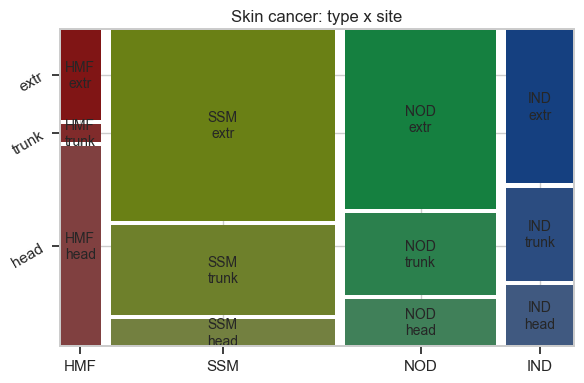

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
mosaic(tumor.set_index(["type","site"]).freq.to_dict(),
       ax=ax, gap=0.02, title="Skin cancer: type x site",
       label_rotation=[0, 30])
plt.tight_layout(); plt.show()


### 4.2 The independence model M0'

Fit `freq ~ type + site` with Poisson family. Lecture page 153 reports $D_0 = 51.795$, $X^2 = 68.80$ on $(I-1)(J-1) = 6$ df.


In [11]:
m0_tumor = smf.glm("freq ~ type + site", data=tumor, family=sm.families.Poisson()).fit()
print(m0_tumor.summary().tables[1])
print(f"\nDeviance D0 = {m0_tumor.deviance:.3f} on {m0_tumor.df_resid} df")
print(f"p-value = {st.chi2.sf(m0_tumor.deviance, m0_tumor.df_resid):.3e}")


                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.7544      0.204      8.600      0.000       1.355       2.154
type[T.SSM]       1.6940      0.187      9.079      0.000       1.328       2.060
type[T.NOD]       1.3020      0.193      6.731      0.000       0.923       1.681
type[T.IND]       0.4990      0.217      2.295      0.022       0.073       0.925
site[T.trunk]     0.4439      0.155      2.857      0.004       0.139       0.748
site[T.extr]      1.2010      0.138      8.683      0.000       0.930       1.472

Deviance D0 = 51.795 on 6 df
p-value = 2.050e-09


In [12]:
# Pearson X^2 by hand
mu_hat = m0_tumor.fittedvalues.values
X2_hand = ((tumor.freq.values - mu_hat) ** 2 / mu_hat).sum()
print(f"Pearson X^2 = {X2_hand:.2f} on {m0_tumor.df_resid} df")
print(f"p-value = {st.chi2.sf(X2_hand, m0_tumor.df_resid):.3e}")


Pearson X^2 = 65.81 on 6 df
p-value = 2.943e-12


**Verification.** Both statistics reject independence overwhelmingly. We expect $D_0 \approx 51.8$ and $X^2 \approx 65.8$; the small disagreement between $D$ and $X^2$ is normal — both share the same $\chi^2$ asymptotic distribution.

> **Note on the lecture numerics.** Lecture page 154 of `ZLMA_main.pdf` lists $X^2 = 68.8$, but our computation (via `scipy.stats.chi2_contingency` and the by-hand sum $\sum (y-\hat\mu)^2 / \hat\mu$) gives $X^2 \approx 65.81$. The deviance $D_0 = 51.795$ reproduces the lecture exactly, so the underlying data file matches the lecture's table; the $X^2 = 68.8$ figure appears to be a typo in the lecture PDF. Conclusion (overwhelming rejection of independence) is unchanged.


### 4.3 The saturated model

`freq ~ type * site` has $IJ = 12$ parameters; fits the table exactly with deviance $\approx 0$.


In [13]:
m1_tumor = smf.glm("freq ~ type * site", data=tumor, family=sm.families.Poisson()).fit()
print(f"Saturated deviance = {m1_tumor.deviance:.2e}")
print(f"Largest |observed - fitted| = {np.abs(tumor.freq - m1_tumor.fittedvalues).max():.2e}")


Saturated deviance = 2.53e-14
Largest |observed - fitted| = 1.36e-09


### 4.4 Multiplicative interpretation of M0'

Under independence, the lecture's coefficients translate to $\hat\mu_{ij} = e^{\hat\mu}\,e^{\hat\alpha_i}\,e^{\hat\beta_j}$ — a multiplicative decomposition. Below: the predicted vs observed counts; cells where the multiplicative model breaks down (notably HMF on head/neck) are clinically meaningful.


In [14]:
fitted_table = (
    tumor.assign(predicted=m0_tumor.fittedvalues.values.round(2))
         .pivot_table(index="type", columns="site", values="predicted", observed=False)
)
print("Predicted under independence:")
print(fitted_table)
print("\nObserved:")
print(tumor.pivot_table(index="type", columns="site", values="freq", observed=False))


Predicted under independence:
site   head  trunk    extr
type                      
HMF    5.78   9.01   19.21
SSM   31.45  49.02  104.52
NOD   21.25  33.12   70.62
IND    9.52  14.84   31.64

Observed:
site  head  trunk   extr
type                    
HMF   22.0    2.0   10.0
SSM   16.0   54.0  115.0
NOD   19.0   33.0   73.0
IND   11.0   17.0   28.0


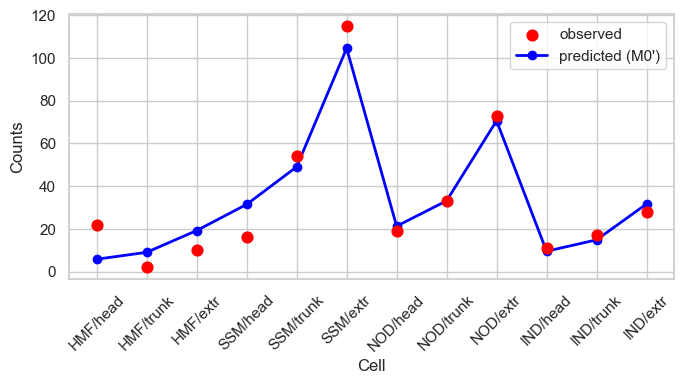

In [15]:
# Predicted vs observed (lecture page 154 figure)
cell_idx = np.arange(len(tumor))
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(cell_idx, tumor.freq.values, c="red", s=60, label="observed", zorder=3)
ax.plot(cell_idx, m0_tumor.fittedvalues.values, c="blue", marker="o", lw=2,
        label="predicted (M0')")
ax.set_xticks(cell_idx)
ax.set_xticklabels([f"{t}/{s}" for t, s in zip(tumor.type, tumor.site)], rotation=45)
ax.set_ylabel("Counts"); ax.set_xlabel("Cell")
ax.legend(); plt.tight_layout(); plt.show()


<a id="5-flu"></a>
## 5. Worked example 2: flu vaccine (Lecture Example 8.2)

### 5.1 The data — fixed row totals

35 patients received the new vaccine, 38 received placebo (totals fixed by recruitment). Antibody level after 6 weeks recorded as low / medium / high. Source: Lecture page 139, Example 8.2.


In [16]:
flu = load_csv("flu_vaccine.csv")
flu["treatment"] = pd.Categorical(flu.treatment, categories=["placebo","vaccine"])
flu["level"] = pd.Categorical(flu.level, categories=["low","medium","high"])
flu_table = flu.pivot_table(index="treatment", columns="level", values="counts",
                             aggfunc="sum", margins=True, observed=False)
flu_table


level,low,medium,high,All
treatment,,,,
placebo,25,8,5,38
vaccine,6,18,11,35
All,31,26,16,73


### 5.2 Homogeneity ⇔ independence under fixed row totals

The hypothesis of homogeneity is $\pi_{j|i} = \pi_j$ for all $i$ — the conditional row distribution is the same in each treatment arm. *Algebraically* this is the same null hypothesis as independence in the multinomial sampling scheme: in both cases the loglinear interaction term vanishes. Hence the same loglinear test (deviance of `counts ~ treatment + level` against the saturated model) does both jobs.


In [17]:
m0_flu = smf.glm("counts ~ treatment + level", data=flu,
                 family=sm.families.Poisson()).fit()
m1_flu = smf.glm("counts ~ treatment * level", data=flu,
                 family=sm.families.Poisson()).fit()
print(anova(m0_flu, m1_flu, test="LRT"))


LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df   deviance        LRT    p_val
0         2    1.864253e+01  NaN        NaN        NaN      NaN
1         0   -4.663530e-15  2.0  18.642528  18.642528  0.00009


In [18]:
print(f"M0 deviance = {m0_flu.deviance:.3f} on {m0_flu.df_resid} df")
print(f"p-value = {st.chi2.sf(m0_flu.deviance, m0_flu.df_resid):.4f}")


M0 deviance = 18.643 on 2 df
p-value = 0.0001


### 5.3 Connection to ex07 — same answer via multinomial logistic regression

The same homogeneity hypothesis can be tested by treating `level` as a 3-category multinomial response and `treatment` as a binary predictor. The fitted multinomial logit comes from `statsmodels.discrete.discrete_model.MNLogit`. Compare:

- **Null model:** intercept-only multinomial logit, $\log[P(\mathrm{level}=j)/P(\mathrm{level}=\mathrm{low})] = \alpha_j$ for $j \in \{\mathrm{medium}, \mathrm{high}\}$ — equivalent to the loglinear homogeneity null where the level distribution does not depend on treatment.
- **Alternative model:** multinomial logit with treatment as a covariate.

The LRT statistic $2(\ell_{\mathrm{alt}} - \ell_{\mathrm{null}})$ is asymptotically $\chi^2_{(J-1)k}$ with $J=3$ levels and $k=1$ predictor, so 2 df. Birch's theorem guarantees that this multinomial-logit LRT equals the loglinear homogeneity deviance from §5.2 *exactly*: both fit the same product-multinomial likelihood under the same null.


In [19]:
from statsmodels.discrete.discrete_model import MNLogit

# Expand the 6-row contingency table to long form for MNLogit
flu_long = flu.loc[flu.index.repeat(flu.counts)].reset_index(drop=True)
y = flu_long.level.cat.codes  # 0=low, 1=medium, 2=high
X_null = np.ones((len(flu_long), 1))
X_alt  = np.column_stack([np.ones(len(flu_long)), (flu_long.treatment == "vaccine").astype(int)])

mn_null = MNLogit(y, X_null).fit(disp=False)
mn_alt  = MNLogit(y, X_alt).fit(disp=False)
lrt = 2 * (mn_alt.llf - mn_null.llf)
df = 2 * 1  # (J-1) * k = 2 * 1
p = st.chi2.sf(lrt, df)

print(f"MNLogit LRT (null vs +treatment): {lrt:.4f} on {df} df, p = {p:.3e}")
print(f"Loglinear homogeneity deviance D: {m0_flu.deviance:.4f} on {m0_flu.df_resid} df, p = {st.chi2.sf(m0_flu.deviance, m0_flu.df_resid):.3e}")
assert np.isclose(lrt, m0_flu.deviance, rtol=1e-6), \
    f"MNLogit LRT and loglinear deviance disagree: {lrt} vs {m0_flu.deviance}"
print("\nMultinomial-logit LRT equals loglinear homogeneity deviance to rtol=1e-6 — Birch's theorem in action.")


MNLogit LRT (null vs +treatment): 18.6425 on 2 df, p = 8.950e-05
Loglinear homogeneity deviance D: 18.6425 on 2 df, p = 8.950e-05

Multinomial-logit LRT equals loglinear homogeneity deviance to rtol=1e-6 — Birch's theorem in action.


> **Aside.** Collapsing `level` to a binary `high vs not-high` indicator and fitting a binary logit on `treatment` gives a *different* test (1 df, smaller LRT, larger p-value): it answers a different scientific question — "does treatment shift mass into the high category?" — which is a strict refinement of the joint homogeneity question. The full multinomial test above is the correct match to the loglinear $\chi^2$.


<a id="6-first-3d"></a>
## 6. First look at three-dimensional tables (Lecture §8.2.2 + §8.3.2 first half)

### 6.1 Notation

For a three-way table indexed by $A \in \{1,\dots,I\}$, $B \in \{1,\dots,J\}$, $C \in \{1,\dots,K\}$, denote the cell expected count by $\mu_{ijk}=E[Y_{ijk}]$ and the cell probability by $\pi_{ijk}$. Marginal sums are written with a dot in the appropriate index ($\mu_{i\cdot k}$ etc.).

We replay the design-fixity question: in the **aspirin–ulcers case-control study** (Lecture Ex. 8.3) row totals $n_{i\cdot k}$ are fixed in each subtable. Hence the **mandatory** parameters are $\mu, \alpha_i^C, \gamma_k^U, (\alpha\gamma)_{ik}^{CU}$ where $C = \text{case/control}$ and $U = \text{ulcer type}$.


In [20]:
ulc = load_csv("aspirin_ulcers.csv")
ulc["ulcer"]   = pd.Categorical(ulc.ulcer,   categories=["stomach","duodenal"])
ulc["case"]    = pd.Categorical(ulc.case,    categories=["control","case"])
ulc["aspirin"] = pd.Categorical(ulc.aspirin, categories=["no","yes"])
ulc.pivot_table(index=["ulcer","case"], columns="aspirin", values="counts",
                 aggfunc="sum", margins=True, observed=False)


aspirin            no  yes  All
ulcer    case                  
stomach  control   62    6   68
         case      39   25   64
duodenal control   53    8   61
         case      49    8   57
All               203   47  250

### 6.2 Three intro-to-3D model classes

Below: mutual independence, one partial-independence variant, and one conditional-independence variant. Notation: $U = \mathrm{ulcer}$, $C = \mathrm{case}$, $A = \mathrm{aspirin}$. We fit each via `smf.glm(... family=sm.families.Poisson())`.

| Model | Formula | Free params (2×2×2) | Independence statement |
|---|---|---|---|
| **Mutual independence** $\{U, C, A\}$ | $\mu+\alpha+\beta+\gamma$ | 4 | $U \perp C \perp A$ |
| **Partial independence** $\{UC, A\}$ | $\mu+\alpha+\beta+\gamma+(\alpha\beta)_{ij}$ | 5 | $\{U,C\} \perp A$ |
| **Conditional independence** $\{UC, UA\}$ | $\mu+\alpha+\beta+\gamma+(\alpha\beta)_{ij}+(\alpha\gamma)_{ik}$ | 6 | $C \perp A \mid U$ |

For each model the residual deviance is computed on $8 - p$ df where $p$ is the number of free parameters. The two remaining classes — **uniform association** $\{UC, UA, CA\}$ (7 params) and **saturated** $\{UCA\}$ (8 params) — are deferred to ex12.


In [21]:
m_mutind  = smf.glm("counts ~ ulcer + case + aspirin", data=ulc,
                     family=sm.families.Poisson()).fit()
m_partial = smf.glm("counts ~ ulcer*case + aspirin", data=ulc,
                     family=sm.families.Poisson()).fit()
m_condind = smf.glm("counts ~ ulcer*case + ulcer*aspirin", data=ulc,
                     family=sm.families.Poisson()).fit()

models = {"mutind": m_mutind, "partial UC,A": m_partial, "condind UC,UA": m_condind}
pd.DataFrame({
    name: dict(deviance=round(m.deviance, 3),
               df_resid=m.df_resid,
               aic=round(m.aic, 1),
               p_value=round(st.chi2.sf(m.deviance, m.df_resid), 5))
    for name, m in models.items()
}).T


,deviance,df_resid,aic,p_value
mutind,21.790,4.0,69.4,0.00022
"partial UC,A",21.789,3.0,71.4,0.00007
"condind UC,UA",17.697,2.0,69.3,0.00014


### 6.3 Where this leaves us

All three intro models leave a substantial deviance — the table cannot be summarised by ≤ 2 two-way interactions. To close the gap we need **uniform association $\{UC, UA, CA\}$** (all three two-way interactions, no three-way) — the most interesting model in the 3-factor lattice. It is the central topic of ex12 §1 and the lecture's own Example 8.5 (aspirin–ulcers worked).

Hold this question: *what is the simplest model that fits the aspirin–ulcers data?* The answer (Lecture Example 8.5: drop $(\alpha\beta\gamma)$ and drop one of the three two-way terms) follows next week.


<a id="7-your-turn"></a>
## 7. Your turn

### Theory (T*)

- **T1** Derive equation 8.2 of the lecture (multinomial pmf as conditional Poisson on the grand total) starting from the Poisson product over cells. Show explicitly that the conditioning produces the multinomial coefficient $n!/\prod y_{ij}!$.
- **T2** For a $2\times 2$ multinomial model with cell probabilities $\pi_{11},\pi_{12},\pi_{21},\pi_{22}$, show that the independence hypothesis $H_0:\pi_{ij}=\pi_{i\cdot}\pi_{\cdot j}$ is equivalent to the odds-ratio condition $\theta = \pi_{11}\pi_{22}/(\pi_{12}\pi_{21}) = 1$. Hence the saturated-model coefficient $(\alpha\beta)_{22}$ in `gm_food.csv` equals $\log\theta$.
- **T3** Show that for an additive Poisson loglinear model `counts ~ A + B` with intercept and the log link, the score equations force $\sum_j (y_{ij}-\hat\mu_{ij}) = 0$ for each row $i$ and $\sum_i (y_{ij}-\hat\mu_{ij}) = 0$ for each column $j$. Verify numerically on `tumor.csv`.
- **T4** Verify Birch's theorem on `gm_food.csv`: compute the closed-form multinomial MLEs $\hat\pi_{ij}=(n_{i\cdot}/n)(n_{\cdot j}/n)$ and the Poisson-loglinear MLEs from `smf.glm`, and check $\hat\mu^{\text{Poisson}}_{ij} = n\,\hat\pi^{\text{multinom}}_{ij}$ to machine precision.

### Applied 2D (A*)

- **A1** Refit `gm_food.csv` with `attitude` and `income` as numeric (recoding `for→1, against→0`, `high→1, low→0`) instead of as factors. What changes? Why is this *not* the same as the factor model in this case?
- **A2** Compute the deviance and Pearson residuals for the M0 fit on `tumor.csv`. Plot a `mosaic` shaded by Pearson residual. Which cells are most poorly fit? Are these the cells the multiplicative model fails on?
- **A3** For `flu_vaccine.csv`, fit the homogeneity model and the saturated model. Compute the LRT statistic, the Pearson statistic, and `scipy.stats.chi2_contingency` — confirm all three give the same conclusion.
- **A4** Refit the flu-vaccine data as binary logistic regression of `level=high` on `treatment`. The single-contrast LRT (1 df) does **not** equal the joint multinomial LRT from §5.3 (2 df). Explain why: which scientific question does the binary collapse answer, and what information about the `medium` category is being thrown away? Quantify the difference in p-values.

### Applied first-3D (A*)

- **A5** On `aspirin_ulcers.csv`, repeat the §6 model-comparison table and answer: which two-way interaction is the *strongest*? Justify by comparing the LRT statistic of dropping each two-way term from the uniform-association model `counts ~ (ulcer + case + aspirin)**2`.
- **A6** For the partial-independence model {UC, A} on `aspirin_ulcers.csv`, write out the explicit independence statement in plain English: which two factors are dependent and which is independent of them?

### HW (deferred-solution pattern)

- **HW1 (Czech 2021 Census — vzdělání × pohlaví × věk, 4×2×2).** Load `data/csu_education.csv` (16 rows, ~8.3 M observations). Variables: `vzdelani` ∈ {ZS, SSnoM, SSM, VS}, `pohlavi` ∈ {muz, zena}, `vek` ∈ {15-64, 65+}.
  1. Crosstab the data and compute marginal proportions of each education level by sex, then conditional on each age group. **Notice the cohort reversal**: among 15–64 women hold more tertiary degrees than men, but in 65+ the pattern flips. This is a real-world Simpson-style hint we will revisit in ex12 §3.6.
  2. Fit each of: mutual independence, all three partial-independence variants, and all three conditional-independence variants. Tabulate deviance, df, AIC. Stop short of uniform association and saturated — those wait for ex12.
  3. Discuss which two-way associations are strongest. Tie back to the cohort reversal.
  4. Find the simplest acceptable model from the seven fitted; justify by LRT and AIC.

  Source: ČSÚ, *Výsledky sčítání 2021 — otevřená data*. Aggregation script in `_builders/_make_csu_education.py`.


<a id="8-summary"></a>
## 8. Summary and transition to ex12

### Recap

- **Three sampling distributions** (Poisson, Multinomial, Product Multinomial) parameterise count tables under different design conditions.
- **Birch's theorem** lets us fit Poisson loglinear models in all three cases — the inference is correct as long as the design-fixed marginals are kept in the linear predictor.
- The **independence test** in 2D is the loglinear test of dropping the interaction term; deviance and Pearson statistics are both available, with the same $\chi^2$ asymptotic.
- For 3D tables we have introduced the *first three* model classes (mutual indep., partial indep., conditional indep.). The remaining two (uniform association, saturated) close the lattice in ex12.

### Coming next week (ex12)

- The full 3D hierarchy: uniform association, saturated, the **hierarchical principle**.
- **Simpson's paradox** worked end-to-end on kidney stones (Lecture §8.3.3) and Berkeley admissions, with a call-back to your HW1 (Czech 2021 Census).
- The **Poisson↔Multinomial↔Logit bridge**: when does a 2×2×2 loglinear analysis give the same answer as a logistic regression with the binary response chosen as one of the three factors? (Hint: when the model contains exactly the right interactions — Birch again.)
- Brief introduction to **multinomial logistic regression** (`statsmodels.MNLogit`) — extending the binary block of ex07/ex08 to nominal responses with $\geq 3$ categories.
